# Tutorial 9: Diagnosing Image Quality

Before building a pipeline, it helps to assess the quality of your plate
images. PhenoTypic's diagnostics plotter gives you objective metrics for
noise, contrast, and structure — so you can make informed decisions about
which enhancers and detectors to use.

**What you will learn:**

1. Use `image.plot.diagnostics()` to assess plate quality
2. Interpret the noise, contrast, and structure metrics
3. Use quality metrics to guide pipeline design

## Imports

In [1]:
from phenotypic.data import load_yeast_plate
import matplotlib.pyplot as plt  # diagnostics() returns matplotlib figures

## Load the Plate

In [2]:
plate = load_yeast_plate()
plate.dash()

## Run Diagnostics

The `.plot.diagnostics()` method produces a multi-panel figure and returns
a dictionary of quantitative metrics. This is one place where matplotlib
output is expected — the diagnostics figure is a static multi-panel layout.

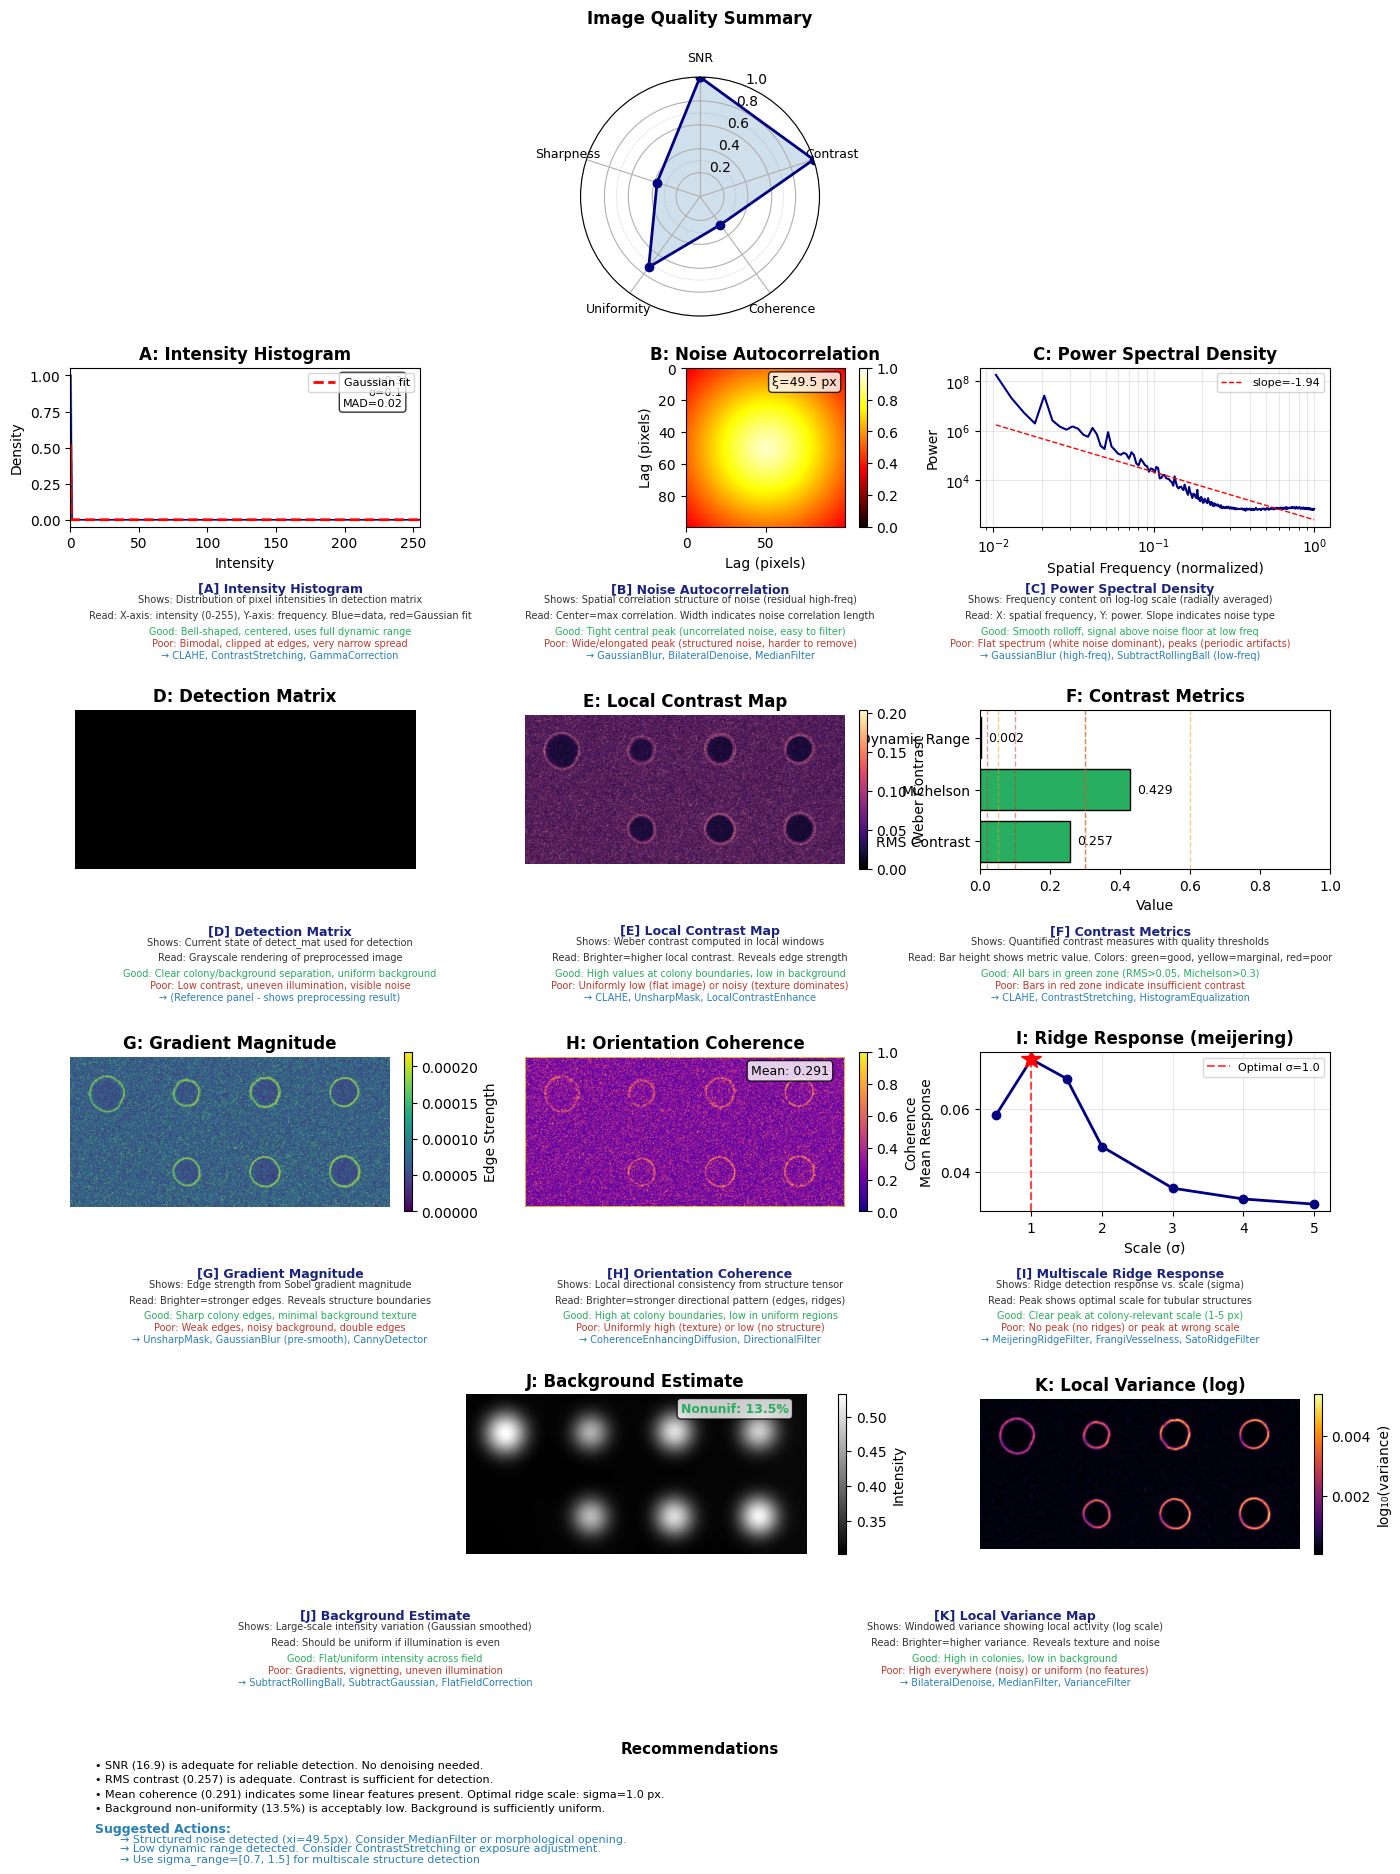

In [3]:
fig, metrics = plate.plot.diagnostics()

## Inspect the Metrics

The `metrics` dictionary contains objective measurements organized by
category. Let's look at each one.

In [4]:
print("Available metric categories:")
for category in metrics:
    print(f"  {category}")

Available metric categories:
  bit_depth
  noise
  contrast
  structure
  background
  quality_scores
  interpretations
  recommendations


### Noise Metrics

Noise metrics tell you how much random variation exists in the image
background. High noise can confuse detectors.

In [5]:
if "noise" in metrics:
    print("Noise metrics:")
    for key, val in metrics["noise"].items():
        if isinstance(val, (int, float)):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

Noise metrics:
  snr: 16.8730
  sigma_mad: 0.0197
  correlation_length: 49.5000


- **SNR** (Signal-to-Noise Ratio) — higher is better. Values below 10
  suggest the image would benefit from denoising (`StableDenoise` or
  `GaussianBlur`).
- **Correlation length** — longer correlation suggests structured noise
  (e.g., uneven illumination) rather than random pixel noise.

### Contrast Metrics

Contrast metrics measure how well colonies separate from the agar
background.

In [6]:
if "contrast" in metrics:
    print("Contrast metrics:")
    for key, val in metrics["contrast"].items():
        if isinstance(val, (int, float)):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

Contrast metrics:
  rms_contrast: 0.2567
  michelson: 0.4287
  dynamic_range: 0.0022
  p1: 0.2520
  p99: 0.6302


- **RMS contrast** — overall contrast level. Low values mean faint
  colonies that may need `CLAHE` to boost local contrast.
- **Michelson contrast** — ratio of (max − min) / (max + min). Values
  close to 1.0 indicate strong colony/agar separation.
- **Dynamic range** — fraction of the bit depth in use. Low dynamic
  range suggests the image is under-exposed.

### Structure Metrics

Structure metrics assess the spatial organization of the image.

In [7]:
if "structure" in metrics:
    print("Structure metrics:")
    for key, val in metrics["structure"].items():
        if isinstance(val, (int, float)):
            print(f"  {key}: {val:.4f}")
        else:
            print(f"  {key}: {val}")

Structure metrics:
  mean_coherence: 0.2913
  optimal_scale: 1.0000
  peak_response: 0.0756
  ridge_responses: [0.05793954400883872, 0.07563562324701593, 0.06950456032556798, 0.04796234141535493, 0.03477529722230368, 0.03136497550995987, 0.02972701604558307]
  scales: [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]
  ridge_method: meijering


- **Gradient mean** — average edge strength. Higher values mean sharper
  colony boundaries, which makes detection easier.
- **Coherence** — consistency of edge orientation. High coherence on grid
  plates suggests well-organized colonies.

## Other Plot Methods

The `.plot` accessor offers additional visualization tools beyond
diagnostics. Here are a few useful ones:

- **`plate.plot.all()`** — side-by-side view of RGB, grayscale, detect_mat, and masks
- **`plate.plot.size_distribution()`** — histogram of colony sizes (requires detection)
- **`plate.plot.morph_progression()`** — morphological operations at increasing scales
- **`plate.plot.try_thresh()`** — visual comparison of threshold methods

In [8]:
plt.close("all")

## Summary

You now know how to assess plate image quality before committing to a
pipeline:

- **`plate.plot.diagnostics()`** — multi-panel figure + metrics dictionary
- **Noise metrics** guide denoising decisions (SNR, correlation length)
- **Contrast metrics** guide enhancement decisions (RMS contrast, dynamic range)
- **Structure metrics** assess colony edge quality (gradient, coherence)

Use these metrics to choose between enhancers, detectors, and prefab
pipelines — rather than guessing.

**Next up:** [Tutorial 10: Detecting Filamentous Fungi](10_detecting_filamentous_fungi.ipynb) —
handle branching fungal morphology with PhenoTypic's specialized detector.